# Food-11 — Accuracy Improvements

Builds on the best config from `train.ipynb` Sec 6:
- **Baseline**: EfficientNet-B0, SGD (lr=0.025, mom=0.9, wd=5e-4), cosine LR, Mixup α=0.2, 300 epochs → **val acc 76.79%**

Improvements applied in order:
1. **Sec 7** — Label Smoothing (ε = 0.1)
2. **Sec 8** — RandAugment (num_ops=2, magnitude=9)
3. **Sec 9** — EMA (Exponential Moving Average, decay=0.9995)
4. **Sec 10** — SAM (Sharpness-Aware Minimisation, ρ=0.05)
5. **Sec 11** — TTA (Test-Time Augmentation, 5 random passes)
6. **Sec 12** — Combined Best (LS + RA + EMA + SAM + TTA)


## 0 — Setup

In [1]:
import os, time, contextlib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json, shutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
import wandb

ROOT = os.path.expanduser('~/QIAO0042/models/ineedfood/')
os.chdir(ROOT)

print(f'PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

PyTorch 2.10.0+cu128  |  CUDA: True
Device: cuda


In [2]:
# Load dataset stats
STATS_FILE = 'dataset/stats.json'
with open(STATS_FILE) as f:
    _stats = json.load(f)
MEAN        = _stats['mean']
STD         = _stats['std']
NUM_CLASSES = _stats['num_classes']
NFS_CACHE   = _stats['nfs_cache']

# Sync NFS → /tmp
LOCAL_CACHE = '/tmp/ineedfood_100x100'

def _sync_to_tmp(src, dst):
    src, dst = Path(src), Path(dst)
    for split in ('training', 'validation', 'evaluation'):
        s, d = src / split, dst / split
        n_s = len(list(s.rglob('*.jpg')))
        n_d = len(list(d.rglob('*.jpg'))) if d.exists() else 0
        if n_d == n_s:
            print(f'  {split:12s} — /tmp ok ({n_d} files)')
        else:
            print(f'  {split:12s} — copying {n_s} files ...')
            if d.exists(): shutil.rmtree(d)
            shutil.copytree(s, d)

if not Path(LOCAL_CACHE).exists():
    _sync_to_tmp(NFS_CACHE, LOCAL_CACHE)
else:
    print(f'Cache already at {LOCAL_CACHE}')

TRAIN_DIR = str(Path(LOCAL_CACHE) / 'training')
VAL_DIR   = str(Path(LOCAL_CACHE) / 'validation')
TEST_DIR  = str(Path(LOCAL_CACHE) / 'evaluation')
print(f'Dirs ready.')

Cache already at /tmp/ineedfood_100x100
Dirs ready.


In [3]:
class Food11Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = Path(root_dir)
        self.transform = transform
        self.samples = []
        exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        for p in self.root.iterdir():
            if p.is_file() and p.suffix.lower() in exts:
                stem = p.stem
                if '_' not in stem: continue
                cls = int(stem.split('_')[0])
                self.samples.append((p, cls))
        if not self.samples:
            raise RuntimeError(f'No images in {root_dir}')
        self.classes = [str(i) for i in range(11)]
        self.class_to_idx = {c: int(c) for c in self.classes}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

In [4]:
# ── Transforms ───────────────────────────────────────────────────────────────
BASE_TRAIN_TRANSFORM = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.Pad(padding=12, fill=0),
    T.RandomCrop(100),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

EVAL_TRANSFORM = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

BATCH_SIZE  = 128
NUM_WORKERS = 10

# Base train loader (Sec 7 reuses this; Sec 8+ uses RA loader)
base_train_dataset = Food11Dataset(TRAIN_DIR, transform=BASE_TRAIN_TRANSFORM)
base_train_loader  = DataLoader(base_train_dataset, batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

val_dataset  = Food11Dataset(VAL_DIR,  transform=EVAL_TRANSFORM)
test_dataset = Food11Dataset(TEST_DIR, transform=EVAL_TRANSFORM)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(base_train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}')

Train: 9866  Val: 3430  Test: 3347


In [5]:
BEST_LR     = 0.025
BEST_WD     = 5e-4
NUM_EPOCHS  = 300
ALPHA_MIXUP = 0.2
WANDB_PROJECT = 'ineedfood'

_AMP_CTX = dict(device_type=DEVICE.type, dtype=torch.bfloat16,
                enabled=(DEVICE.type == 'cuda'))

def build_model(num_classes=NUM_CLASSES):
    model = efficientnet_b0(weights=None)
    in_f = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_f, num_classes)
    return model.to(DEVICE)


def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_one_epoch(model, loader, optimizer, criterion, ema=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.autocast(**_AMP_CTX):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        if ema is not None:
            ema.update(model)   # per-batch EMA update
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.detach().argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def train_one_epoch_mixup(model, loader, optimizer, criterion, alpha=0.2, ema=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        mixed, y_a, y_b, lam = mixup_data(imgs, labels, alpha)
        optimizer.zero_grad()
        with torch.autocast(**_AMP_CTX):
            logits = model(mixed)
            loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        loss.backward()
        optimizer.step()
        if ema is not None:
            ema.update(model)   # per-batch EMA update
        total_loss += loss.item() * imgs.size(0)
        pred = logits.detach().argmax(1)
        correct += (lam * (pred == y_a).float() + (1-lam) * (pred == y_b).float()).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.autocast(**_AMP_CTX):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def run_training(model, train_loader, val_loader, optimizer, criterion,
                 num_epochs, scheduler=None, alpha=None, tag='',
                 wandb_run=None, ema=None, ckpt_path=None):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        # ema passed into epoch fn for per-batch updates
        if alpha is not None:
            tr_loss, tr_acc = train_one_epoch_mixup(model, train_loader, optimizer, criterion, alpha, ema=ema)
        else:
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, ema=ema)
        # Evaluate with EMA weights if available, else with live weights
        if ema is not None:
            with ema.apply_shadow(model):
                vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        else:
            vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if ckpt_path is not None and vl_acc == max(history['val_acc']):
            os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_acc': vl_acc, 'val_loss': vl_loss,
                        'tag': tag}, ckpt_path)
            print(f'  [ckpt] epoch {epoch}  val_acc={vl_acc:.4f}  -> {ckpt_path}')
        if wandb_run is not None:
            wandb_run.log({'train_loss': tr_loss, 'val_loss': vl_loss,
                           'train_acc':  tr_acc,  'val_acc':  vl_acc})
        elapsed = time.time() - t0
        if epoch % 10 == 0 or epoch <= 5 or epoch == num_epochs:
            print(f'[{tag}] Epoch {epoch:3d}/{num_epochs}  '
                  f'loss {tr_loss:.4f}/{vl_loss:.4f}  '
                  f'acc {tr_acc:.3f}/{vl_acc:.3f}  ({elapsed:.1f}s)')
    return history


def plot_curves(histories, labels, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors
    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        eps = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(eps, hist['train_loss'], color=c, ls='-',  label=f'{lbl} train')
        axes[0].plot(eps, hist['val_loss'],   color=c, ls='--', label=f'{lbl} val')
        axes[1].plot(eps, hist['train_acc'],  color=c, ls='-',  label=f'{lbl} train')
        axes[1].plot(eps, hist['val_acc'],    color=c, ls='--', label=f'{lbl} val')
    for ax, yl in zip(axes, ['Loss', 'Accuracy']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(yl)
        ax.set_title(f'{title} — {yl}'); ax.legend(fontsize=8)
    plt.tight_layout()
    fname = title.replace(' ', '_') + '.png'
    plt.savefig(fname, dpi=150)
    plt.show()


def report_final(history, tag):
    tl  = history['train_loss'][-1]
    vl  = history['val_loss'][-1]
    ta  = history['train_acc'][-1]
    va  = history['val_acc'][-1]
    bva = max(history['val_acc'])
    print(f'=== {tag} ===')
    print(f'  Train  loss/acc : {tl:.4f} / {ta:.4f}')
    print(f'  Val    loss/acc : {vl:.4f} / {va:.4f}')
    print(f'  Best val acc   : {bva:.4f}')


print('All utility functions ready.')


---
## 7 — Label Smoothing (ε = 0.1)

**What it does**: Instead of training against hard one-hot targets (probability 1.0 on the correct class), label smoothing assigns `1 − ε` to the correct class and distributes `ε` uniformly across all other classes:

$$y_{\text{smooth}} = (1 - \varepsilon)\, y_{\text{hard}} + \frac{\varepsilon}{K}$$

**Why it helps**: Prevents the model from becoming over-confident, acts as a regulariser, and has been shown to improve calibration and generalisation on small datasets.  
**Baseline** (Sec 6 Mixup, no LS): val acc **76.79%**

In [ ]:
NUM_EPOCHS_7 = 300
CKPT_SEC7    = 'checkpoints/sec7_label_smooth_best.pth'

run7 = wandb.init(
    project=WANDB_PROJECT,
    name='sec7-label-smoothing',
    config={
        'section': 7, 'lr': BEST_LR, 'weight_decay': BEST_WD,
        'epochs': NUM_EPOCHS_7, 'schedule': 'cosine',
        'mixup_alpha': ALPHA_MIXUP, 'label_smoothing': 0.1,
        'optimizer': 'SGD', 'momentum': 0.9,
        'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0',
    },
)

model7   = build_model()
opt7     = torch.optim.SGD(model7.parameters(), lr=BEST_LR,
                           momentum=0.9, weight_decay=BEST_WD)
sched7   = torch.optim.lr_scheduler.CosineAnnealingLR(opt7, T_max=NUM_EPOCHS_7, eta_min=0.0)
crit7    = nn.CrossEntropyLoss(label_smoothing=0.1)

hist7 = run_training(
    model7, base_train_loader, val_loader,
    opt7, crit7, num_epochs=NUM_EPOCHS_7,
    scheduler=sched7, alpha=ALPHA_MIXUP,
    tag='Sec7-LS', wandb_run=run7,
    ckpt_path=CKPT_SEC7,
)
report_final(hist7, 'Sec7 Label Smoothing')
run7.finish()
print('Section 7 done.')

In [13]:
import wandb
import matplotlib.pyplot as plt

WANDB_ENTITY  = '584832452-nanyang-technological-university-singapore'
WANDB_PROJECT = 'ineedfood'

def fetch_history(run_id, tag=None):
    """
    Retrieve training history from a wandb run, matching the dict format
    returned by run_training:
        {'train_loss': [...], 'val_loss': [...],
         'train_acc':  [...], 'val_acc':  [...]}

    Parameters
    ----------
    run_id : str
        Short run ID (e.g. 'tin2g81l') or full 'entity/project/run_id'.
    tag : str, optional
        Metric prefix logged as '{tag}/train_loss' etc.
        If None, auto-detected. Pass tag='' for bare keys.

    Returns
    -------
    history : dict  – same structure as run_training output
    config  : dict  – hyperparameters stored in the run config
    """
    api  = wandb.Api()
    path = run_id if '/' in run_id else f'{WANDB_ENTITY}/{WANDB_PROJECT}/{run_id}'
    run  = api.run(path)

    df = run.history(samples=10_000, pandas=True)

    # ── Auto-detect tag prefix ────────────────────────────────────────────────
    if tag is None:
        prefixed = [c for c in df.columns if c.endswith('/train_loss')]
        tag = prefixed[0].replace('/train_loss', '') if prefixed else ''

    prefix = f'{tag}/' if tag else ''
    keys = {
        'train_loss': f'{prefix}train_loss',
        'val_loss':   f'{prefix}val_loss',
        'train_acc':  f'{prefix}train_acc',
        'val_acc':    f'{prefix}val_acc',
    }

    missing = [v for v in keys.values() if v not in df.columns]
    if missing:
        available_tags = list({c.rsplit('/', 1)[0] for c in df.columns if '/' in c})
        raise KeyError(
            f"Keys {missing} not found in run '{run.name}'.\n"
            f"  Available tags : {available_tags}\n"
            f"  All keys       : {sorted(df.columns.tolist())}\n"
            f"  Hint: pass tag= explicitly, e.g. fetch_history('{run_id}', tag='{available_tags[0] if available_tags else ''}')"
        )

    sub = df[list(keys.values())].dropna()
    history = {k: sub[v].tolist() for k, v in keys.items()}

    # run.config values are plain Python objects via the API
    config = {k: v for k, v in run.config.items() if not k.startswith('_')}

    print(f"Run  : {run.name}  ({run.id})")
    print(f"Tag  : '{tag}'  |  Steps recovered: {len(sub)}")
    print(f"Config: {config}")
    return history, config


def list_runs(name_filter=None):
    """Print a table of all runs in the project."""
    api  = wandb.Api()
    runs = api.runs(f'{WANDB_ENTITY}/{WANDB_PROJECT}')
    print(f'{"ID":>10}  {"Name":<30}  {"State":>8}  {"Steps":>6}')
    print('-' * 62)
    for r in runs:
        if name_filter and name_filter not in r.name:
            continue
        steps = r.summary.get('_step', '?')
        print(f'{r.id:>10}  {r.name:<30}  {r.state:>8}  {steps!s:>6}')

def plot_curves(histories, labels, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors
    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], color=c, linestyle='-',  label=f'{lbl} train')
        axes[0].plot(epochs, hist['val_loss'],   color=c, linestyle='--', label=f'{lbl} val')
        axes[1].plot(epochs, hist['train_acc'],  color=c, linestyle='-',  label=f'{lbl} train')
        axes[1].plot(epochs, hist['val_acc'],    color=c, linestyle='--', label=f'{lbl} val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

print('wandb history utilities ready.')

wandb history utilities ready.


In [14]:
hist7, _ = fetch_history('esp1xmd9')

Run  : sec7-label-smoothing  (esp1xmd9)
Tag  : ''  |  Steps recovered: 300
Config: {'lr': 0.025, 'model': 'EfficientNet-B0', 'epochs': 300, 'section': 7, 'momentum': 0.9, 'schedule': 'cosine', 'optimizer': 'SGD', 'batch_size': 128, 'mixup_alpha': 0.2, 'weight_decay': 0.0005, 'label_smoothing': 0.1}


In [15]:
# Reference baseline: Sec6 Mixup val acc 76.79%
BASELINE_VAL_ACC = 0.7679
best7 = max(hist7['val_acc'])
print(f'Baseline (Sec6 Mixup) best val acc : {BASELINE_VAL_ACC:.4f}')
print(f'Sec7 Label Smoothing  best val acc : {best7:.4f}')
print(f'Delta: {best7 - BASELINE_VAL_ACC:+.4f}')

Baseline (Sec6 Mixup) best val acc : 0.7679
Sec7 Label Smoothing  best val acc : 0.7889
Delta: +0.0210


---
## 8 — RandAugment (num\_ops=2, magnitude=9)

**What it does**: At each training step, randomly selects `num_ops` augmentation operations (from a pool of 14 including rotation, shear, colour jitter, posterise, etc.) and applies them with strength `magnitude`.  

**Why it helps**: Provides much richer augmentation diversity than the fixed HFlip+Pad+Crop pipeline, effectively expanding the training set and reducing overfitting. Stacks naturally with Mixup and Label Smoothing.  
**Config**: Adds RA on top of Sec 7 (LS + Mixup + best LR/WD/schedule).

In [6]:
# ── RandAugment training transform ───────────────────────────────────────────
RA_TRAIN_TRANSFORM = T.Compose([
    T.RandAugment(num_ops=2, magnitude=9),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

ra_train_dataset = Food11Dataset(TRAIN_DIR, transform=RA_TRAIN_TRANSFORM)
ra_train_loader  = DataLoader(ra_train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
print(f'RandAugment loader: {len(ra_train_dataset)} images')

RandAugment loader: 9866 images


In [7]:
NUM_EPOCHS_8 = 300

run8 = wandb.init(
    project=WANDB_PROJECT,
    name='sec8-randaugment',
    config={
        'section': 8, 'lr': BEST_LR, 'weight_decay': BEST_WD,
        'epochs': NUM_EPOCHS_8, 'schedule': 'cosine',
        'mixup_alpha': ALPHA_MIXUP, 'label_smoothing': 0.1,
        'augmentation': 'RandAugment', 'ra_num_ops': 2, 'ra_magnitude': 9,
        'optimizer': 'SGD', 'momentum': 0.9,
        'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0',
    },
)

model8  = build_model()
opt8    = torch.optim.SGD(model8.parameters(), lr=BEST_LR,
                          momentum=0.9, weight_decay=BEST_WD)
sched8  = torch.optim.lr_scheduler.CosineAnnealingLR(opt8, T_max=NUM_EPOCHS_8, eta_min=0.0)
crit8   = nn.CrossEntropyLoss(label_smoothing=0.1)

hist8 = run_training(
    model8, ra_train_loader, val_loader,
    opt8, crit8, num_epochs=NUM_EPOCHS_8,
    scheduler=sched8, alpha=ALPHA_MIXUP,
    tag='Sec8-RA', wandb_run=run8,
)
report_final(hist8, 'Sec8 RandAugment')
run8.finish()
print('Section 8 done.')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/msai/qiao0042/.netrc.
wandb: Currently logged in as: 584832452 (584832452-nanyang-technological-university-singapore) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[Sec8-RA] Epoch   1/300  loss 2.4168/2.7323  acc 0.158/0.144  (4.6s)
[Sec8-RA] Epoch   2/300  loss 2.3208/2.7382  acc 0.186/0.219  (3.3s)
[Sec8-RA] Epoch   3/300  loss 2.2450/2.3423  acc 0.222/0.281  (3.6s)
[Sec8-RA] Epoch   4/300  loss 2.1825/2.2169  acc 0.242/0.303  (3.6s)
[Sec8-RA] Epoch   5/300  loss 2.1475/2.0518  acc 0.269/0.328  (3.3s)
[Sec8-RA] Epoch  10/300  loss 2.0368/1.8545  acc 0.325/0.407  (3.4s)
[Sec8-RA] Epoch  20/300  loss 1.9161/1.6995  acc 0.385/0.481  (3.3s)
[Sec8-RA] Epoch  30/300  loss 1.5952/1.4609  acc 0.541/0.611  (3.3s)
[Sec8-RA] Epoch  40/300  loss 1.4392/1.5133  acc 0.618/0.645  (3.3s)
[Sec8-RA] Epoch  50/300  loss 1.4566/1.4348  acc 0.613/0.670  (3.3s)
[Sec8-RA] Epoch  60/300  loss 1.4980/1.3339  acc 0.598/0.651  (3.5s)
[Sec8-RA] Epoch  70/300  loss 1.3406/1.3063  acc 0.672/0.671  (3.3s)
[Sec8-RA] Epoch  80/300  loss 1.3038/1.2835  acc 0.687/0.683  (3.3s)
[Sec8-RA] Epoch  90/300  loss 1.2636/1.2809  acc 0.703/0.681  (3.3s)
[Sec8-RA] Epoch 100/300  loss 1.21

train_acc,▁▃▃▃▄▅▅▅▅▆▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇████▇███
train_loss,█▇▆▆▆▅▄▄▄▄▄▄▅▄▃▃▃▃▃▃▃▂▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▃▁▅▅▅▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
val_loss,█▄▃▂▂▂▄▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▂▁▂▂▂▁▂▂▂▂▁▂▂▃▂▁▂
train_acc,0.89967
train_loss,0.81755
val_acc,0.77668
val_loss,1.3531


Section 8 done.


In [16]:
best8 = max(hist8['val_acc'])
print(f'Baseline (Sec6)          : {BASELINE_VAL_ACC:.4f}')
print(f'Sec7 +LabelSmooth        : {max(hist7["val_acc"]):.4f}')
print(f'Sec8 +LabelSmooth+RA     : {best8:.4f}')

Baseline (Sec6)          : 0.7679
Sec7 +LabelSmooth        : 0.7889
Sec8 +LabelSmooth+RA     : 0.7851


---
## 9 — EMA (Exponential Moving Average, decay = 0.9995)

**What it does**: Maintains a running average of model weights:

$$\theta_{\text{EMA}} \leftarrow d \cdot \theta_{\text{EMA}} + (1-d) \cdot \theta$$

Validation and test inference use the EMA weights (smoother loss landscape).  
**Why it helps**: SGD with momentum can oscillate near minima. EMA weights sit in a flatter basin → better generalisation, often +0.5–2% on val set.  
**Config**: Adds EMA on top of Sec 8 (LS + RA + Mixup).

In [24]:
class EMA:
    """EMA of model parameters + float buffers, updated per batch.

    decay=0.9995 is designed for per-batch updates (~77 batches/epoch).
    Effective window = 1/(1-0.9995) = 2000 batches ≈ 26 epochs.
    Warmup ensures EMA tracks quickly in the first few hundred steps.
    """
    def __init__(self, model, decay=0.9995):
        self.decay = decay
        self.num_updates = 0
        self.shadow = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone().detach()
        for name, buf in model.named_buffers():
            if buf.is_floating_point():
                self.shadow[name] = buf.data.clone().detach()

    @torch.no_grad()
    def update(self, model):
        # Warmup: effective decay ramps from ~0.5 up to self.decay over first ~10 steps
        self.num_updates += 1
        d = min(self.decay, (1 + self.num_updates) / (10 + self.num_updates))
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name].mul_(d).add_(param.data, alpha=1 - d)
        for name, buf in model.named_buffers():
            if buf.is_floating_point():
                self.shadow[name].mul_(d).add_(buf.data, alpha=1 - d)

    def apply_shadow(self, model):
        return _EMACtx(self, model)


class _EMACtx:
    def __init__(self, ema, model):
        self.ema = ema
        self.model = model
        self.backup = {}

    def __enter__(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.ema.shadow[name])
        for name, buf in self.model.named_buffers():
            if name in self.ema.shadow:
                self.backup[name] = buf.data.clone()
                buf.data.copy_(self.ema.shadow[name])

    def __exit__(self, *args):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.backup[name])
        for name, buf in self.model.named_buffers():
            if name in self.backup:
                buf.data.copy_(self.backup[name])


print('EMA ready (per-batch, decay=0.9995 with warmup).')


EMA ready (per-batch, decay=0.9995 with warmup).


In [25]:
NUM_EPOCHS_9 = 300

run9 = wandb.init(
    project=WANDB_PROJECT,
    name='sec9-ema',
    config={
        'section': 9, 'lr': BEST_LR, 'weight_decay': BEST_WD,
        'epochs': NUM_EPOCHS_9, 'schedule': 'cosine',
        'mixup_alpha': ALPHA_MIXUP, 'label_smoothing': 0.1,
        'augmentation': 'RandAugment', 'ra_num_ops': 2, 'ra_magnitude': 9,
        'ema': True, 'ema_decay': 0.9995,
        'optimizer': 'SGD', 'momentum': 0.9,
        'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0',
    },
)

model9 = build_model()
opt9   = torch.optim.SGD(model9.parameters(), lr=BEST_LR,
                         momentum=0.9, weight_decay=BEST_WD)
sched9 = torch.optim.lr_scheduler.CosineAnnealingLR(opt9, T_max=NUM_EPOCHS_9, eta_min=0.0)
crit9  = nn.CrossEntropyLoss(label_smoothing=0.1)
ema9   = EMA(model9, decay=0.9995)

hist9 = run_training(
    model9, ra_train_loader, val_loader,
    opt9, crit9, num_epochs=NUM_EPOCHS_9,
    scheduler=sched9, alpha=ALPHA_MIXUP,
    tag='Sec9-EMA', wandb_run=run9, ema=ema9,
)
report_final(hist9, 'Sec9 EMA')
run9.finish()
print('Section 9 done.')

train_acc,▁▂▂▃▃▃▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▅▆▇▇▇▇▇▇▇█▇█▇█████
train_loss,█▇▇▆▆▅▅▅▅▄▃▄▃▃▃▃▃▃▃▃▂▂▃▃▂▂▂▂▁▂▂▂▁▂▂▁▁▁▁▁
val_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,██▇▇▇▆▆▅▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▂▂▁▁
train_acc,0.69556
train_loss,1.28446
val_acc,0.14577
val_loss,2.34007


[Sec9-EMA] Epoch   1/300  loss 2.4020/2.3280  acc 0.159/0.146  (3.4s)
[Sec9-EMA] Epoch   2/300  loss 2.3213/2.3184  acc 0.191/0.146  (3.5s)
[Sec9-EMA] Epoch   3/300  loss 2.2366/2.3180  acc 0.225/0.148  (3.4s)
[Sec9-EMA] Epoch   4/300  loss 2.1797/2.3020  acc 0.250/0.150  (3.4s)
[Sec9-EMA] Epoch   5/300  loss 2.1313/2.2519  acc 0.275/0.176  (3.4s)
[Sec9-EMA] Epoch  10/300  loss 2.0166/1.9467  acc 0.336/0.377  (3.4s)
[Sec9-EMA] Epoch  20/300  loss 1.6989/1.5058  acc 0.495/0.596  (3.4s)
[Sec9-EMA] Epoch  30/300  loss 1.5994/1.3286  acc 0.547/0.666  (3.3s)
[Sec9-EMA] Epoch  40/300  loss 1.4956/1.2252  acc 0.601/0.704  (3.5s)
[Sec9-EMA] Epoch  50/300  loss 1.4240/1.1733  acc 0.632/0.730  (3.5s)
[Sec9-EMA] Epoch  60/300  loss 1.3763/1.1326  acc 0.650/0.746  (3.4s)
[Sec9-EMA] Epoch  70/300  loss 1.3907/1.1109  acc 0.650/0.753  (3.4s)
[Sec9-EMA] Epoch  80/300  loss 1.2637/1.0988  acc 0.704/0.758  (3.4s)
[Sec9-EMA] Epoch  90/300  loss 1.2450/1.0897  acc 0.718/0.762  (3.4s)
[Sec9-EMA] Epoch 100

train_acc,▁▁▃▄▄▅▅▅▅▅▅▅▆▆▅▆▆▆▆▆▆▆▇▆▇▆▇▇▇▇▇▇▇█▇▇▇▇██
train_loss,██▇▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▃▃▂▃▃▂▂▂▁▂▂▁▁▁▂▁▁▁▁▁▁
val_acc,▁▂▃▅▆▇▇▇▇▇▇▇████████████████████████████
val_loss,█▆▄▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,0.89861
train_loss,0.82258
val_acc,0.79067
val_loss,1.08157


Section 9 done.


In [26]:
best9 = max(hist9['val_acc'])
print(f'Baseline (Sec6)               : {BASELINE_VAL_ACC:.4f}')
print(f'Sec7 +LabelSmooth             : {max(hist7["val_acc"]):.4f}')
print(f'Sec8 +LabelSmooth+RA          : {max(hist8["val_acc"]):.4f}')
print(f'Sec9 +LabelSmooth+RA+EMA      : {best9:.4f}')

Baseline (Sec6)               : 0.7679
Sec7 +LabelSmooth             : 0.7889
Sec8 +LabelSmooth+RA          : 0.7851
Sec9 +LabelSmooth+RA+EMA      : 0.7918


---
## 10 — SAM (Sharpness-Aware Minimisation, ρ = 0.05)

**What it does**: Each update takes two forward-backward passes:
1. **First pass** — computes gradient, perturbs weights by ρ in the gradient direction (moves to a sharper region).
2. **Second pass** — computes gradient at the perturbed point, restores original weights, then updates with the perturbed gradient.

This finds parameters that lie in *flat* loss basins rather than sharp minima → better generalisation.  
**Trade-off**: ~2× training time per epoch.  
**Config**: Adds SAM on top of Sec 8 stack (LS + RA + Mixup). EMA is *not* stacked here to keep the comparison clean; Sec 12 combines all.

In [27]:
class SAM(torch.optim.Optimizer):
    """Sharpness-Aware Minimisation wrapper around any base optimizer."""
    def __init__(self, params, base_optimizer_cls, rho=0.05, **base_kwargs):
        defaults = dict(rho=rho, **base_kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer_cls(self.param_groups, **base_kwargs)
        self.param_groups   = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (norm + 1e-12)
            for p in group['params']:
                if p.grad is None: continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        dev = self.param_groups[0]['params'][0].device
        norms = [p.grad.norm(p=2).to(dev)
                 for group in self.param_groups
                 for p in group['params']
                 if p.grad is not None]
        return torch.norm(torch.stack(norms), p=2)

    def step(self, closure=None):
        raise NotImplementedError('Use first_step / second_step')


def train_one_epoch_sam(model, loader, optimizer, criterion, alpha=None):
    """SAM training epoch. Supports optional Mixup (alpha != None)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        if alpha is not None:
            mixed, y_a, y_b, lam = mixup_data(imgs, labels, alpha)

        # ── First pass: perturb weights ──────────────────────────────────
        with torch.autocast(**_AMP_CTX):
            if alpha is not None:
                logits = model(mixed)
                loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
            else:
                logits = model(imgs)
                loss   = criterion(logits, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # ── Second pass: update at perturbed point ───────────────────────
        with torch.autocast(**_AMP_CTX):
            if alpha is not None:
                loss2 = mixup_criterion(criterion, model(mixed), y_a, y_b, lam)
            else:
                loss2 = criterion(model(imgs), labels)
        loss2.backward()
        optimizer.second_step(zero_grad=True)

        total_loss += loss.item() * imgs.size(0)
        with torch.no_grad():
            pred = logits.detach().argmax(1)
            if alpha is not None:
                correct += (lam * (pred == y_a).float() +
                            (1-lam) * (pred == y_b).float()).sum().item()
            else:
                correct += (pred == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


def run_training_sam(model, train_loader, val_loader, optimizer, criterion,
                     num_epochs, scheduler=None, alpha=None, tag='', wandb_run=None):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch_sam(model, train_loader, optimizer, criterion, alpha)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if wandb_run is not None:
            wandb_run.log({'train_loss': tr_loss, 'val_loss': vl_loss,
                           'train_acc':  tr_acc,  'val_acc':  vl_acc})
        elapsed = time.time() - t0
        if epoch % 10 == 0 or epoch <= 5 or epoch == num_epochs:
            print(f'[{tag}] Epoch {epoch:3d}/{num_epochs}  '
                  f'loss {tr_loss:.4f}/{vl_loss:.4f}  '
                  f'acc {tr_acc:.3f}/{vl_acc:.3f}  ({elapsed:.1f}s)')
    return history


print('SAM class and training loop ready.')

SAM class and training loop ready.


In [28]:
NUM_EPOCHS_10 = 300

run10 = wandb.init(
    project=WANDB_PROJECT,
    name='sec10-sam',
    config={
        'section': 10, 'lr': BEST_LR, 'weight_decay': BEST_WD,
        'epochs': NUM_EPOCHS_10, 'schedule': 'cosine',
        'mixup_alpha': ALPHA_MIXUP, 'label_smoothing': 0.1,
        'augmentation': 'RandAugment', 'ra_num_ops': 2, 'ra_magnitude': 9,
        'sam': True, 'sam_rho': 0.05,
        'base_optimizer': 'SGD', 'momentum': 0.9,
        'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0',
    },
)

model10 = build_model()
opt10   = SAM(model10.parameters(), base_optimizer_cls=torch.optim.SGD,
              rho=0.05, lr=BEST_LR, momentum=0.9, weight_decay=BEST_WD)
sched10 = torch.optim.lr_scheduler.CosineAnnealingLR(
              opt10.base_optimizer, T_max=NUM_EPOCHS_10, eta_min=0.0)
crit10  = nn.CrossEntropyLoss(label_smoothing=0.1)

hist10 = run_training_sam(
    model10, ra_train_loader, val_loader,
    opt10, crit10, num_epochs=NUM_EPOCHS_10,
    scheduler=sched10, alpha=ALPHA_MIXUP,
    tag='Sec10-SAM', wandb_run=run10,
)
report_final(hist10, 'Sec10 SAM')
run10.finish()
print('Section 10 done.')

[Sec10-SAM] Epoch   1/300  loss 2.4149/5.4179  acc 0.158/0.187  (5.6s)
[Sec10-SAM] Epoch   2/300  loss 2.2737/2.8101  acc 0.211/0.283  (5.0s)
[Sec10-SAM] Epoch   3/300  loss 2.1810/2.0951  acc 0.256/0.312  (5.0s)
[Sec10-SAM] Epoch   4/300  loss 2.1212/2.0397  acc 0.277/0.329  (5.1s)
[Sec10-SAM] Epoch   5/300  loss 2.0779/2.0570  acc 0.298/0.339  (5.2s)
[Sec10-SAM] Epoch  10/300  loss 1.9450/1.8002  acc 0.372/0.455  (5.4s)
[Sec10-SAM] Epoch  20/300  loss 1.7417/1.5552  acc 0.476/0.559  (5.1s)
[Sec10-SAM] Epoch  30/300  loss 1.5983/1.3472  acc 0.547/0.643  (5.3s)
[Sec10-SAM] Epoch  40/300  loss 1.4708/1.2648  acc 0.605/0.680  (5.2s)
[Sec10-SAM] Epoch  50/300  loss 1.4805/1.2267  acc 0.607/0.706  (5.3s)
[Sec10-SAM] Epoch  60/300  loss 1.3112/1.1647  acc 0.681/0.723  (5.2s)
[Sec10-SAM] Epoch  70/300  loss 1.3299/1.1833  acc 0.670/0.710  (5.1s)
[Sec10-SAM] Epoch  80/300  loss 1.2669/1.1726  acc 0.702/0.721  (5.2s)
[Sec10-SAM] Epoch  90/300  loss 1.3112/1.3919  acc 0.688/0.725  (5.2s)
[Sec10

train_acc,▁▂▂▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇█▇█▇█▇█████▇█
train_loss,█▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▄▃▂▂▃▂▂▂▂▂▂▂▂▃▂▂▁▁▂▁▂
val_acc,▁▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇██████████████████████
val_loss,█▇▆▅▄▂▃▂▂▂▂▃▂▂▂▂▂▂▂▂▁▁▂▁▁▂▁▁▂▂▁▂▁▂▁▁▂▁▁▁
train_acc,0.86465
train_loss,0.9215
val_acc,0.79504
val_loss,1.01135


Section 10 done.


In [29]:
best10 = max(hist10['val_acc'])
print(f'Baseline (Sec6)               : {BASELINE_VAL_ACC:.4f}')
print(f'Sec7 +LS                      : {max(hist7["val_acc"]):.4f}')
print(f'Sec8 +LS+RA                   : {max(hist8["val_acc"]):.4f}')
print(f'Sec9 +LS+RA+EMA               : {max(hist9["val_acc"]):.4f}')
print(f'Sec10 +LS+RA+SAM              : {best10:.4f}')

Baseline (Sec6)               : 0.7679
Sec7 +LS                      : 0.7889
Sec8 +LS+RA                   : 0.7851
Sec9 +LS+RA+EMA               : 0.7918
Sec10 +LS+RA+SAM              : 0.7980


---
## 11 — TTA (Test-Time Augmentation, n = 5)

**What it does**: At inference, runs each image through `n` random augmentations, averages the softmax probabilities, then takes the argmax.

$$p_{\text{TTA}} = \frac{1}{n+1}\left(p_{\text{det}} + \sum_{i=1}^{n} p_{\text{aug}_i}\right)$$

**Why it helps**: Averaging over stochastic augmentations reduces variance in predictions and is especially effective when combined with strong augmentation (RandAugment).  
**Applied to**: The EMA model from Sec 9 (best val acc without SAM's 2× cost).  
**No retraining needed** — TTA is applied at inference time only.

In [ ]:
@torch.no_grad()
def evaluate_tta(model, dataset_path, criterion, n_aug=5):
    """TTA: 1 deterministic + n_aug random passes, average softmax probs."""
    model.eval()

    # Collect labels once using deterministic transform
    det_ds     = Food11Dataset(dataset_path, transform=EVAL_TRANSFORM)
    det_loader = DataLoader(det_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    labels_all = []
    all_probs  = []

    # Deterministic pass
    probs_det = []
    for imgs, lbls in det_loader:
        labels_all.append(lbls)
        with torch.autocast(**_AMP_CTX):
            probs_det.append(model(imgs.to(DEVICE)).softmax(dim=-1).cpu())
    all_probs.append(torch.cat(probs_det))
    labels_all = torch.cat(labels_all)

    # Random augmented passes
    aug_ds     = Food11Dataset(dataset_path, transform=BASE_TRAIN_TRANSFORM)
    aug_loader = DataLoader(aug_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    for _ in range(n_aug):
        probs_aug = []
        for imgs, _ in aug_loader:
            with torch.autocast(**_AMP_CTX):
                probs_aug.append(model(imgs.to(DEVICE)).softmax(dim=-1).cpu())
        all_probs.append(torch.cat(probs_aug))

    avg_probs = torch.stack(all_probs).mean(0)   # (N, 11)
    preds     = avg_probs.argmax(1)
    acc       = (preds == labels_all).float().mean().item()
    loss      = F.nll_loss(avg_probs.clamp(min=1e-9).log(), labels_all).item()
    return loss, acc


print('TTA evaluate function ready.')

In [ ]:
# Apply EMA weights from Sec9 model for TTA evaluation
crit_eval = nn.CrossEntropyLoss()

# Without TTA (standard deterministic eval with EMA weights)
with ema9.apply_shadow(model9):
    vl_loss_no_tta, vl_acc_no_tta = evaluate(model9, val_loader, crit_eval)

# With TTA (EMA weights + 5 random passes)
with ema9.apply_shadow(model9):
    vl_loss_tta, vl_acc_tta = evaluate_tta(model9, VAL_DIR, crit_eval, n_aug=5)

print('=== Sec11 TTA Results (Sec9 EMA model, val set) ===')
print(f'  Without TTA : {vl_acc_no_tta:.4f}')
print(f'  With TTA    : {vl_acc_tta:.4f}')
print(f'  TTA delta   : {vl_acc_tta - vl_acc_no_tta:+.4f}')

---
## 12 — Combined Best (LS + RA + EMA + SAM)

Trains with all four improvements simultaneously:
- **Label Smoothing** ε = 0.1
- **RandAugment** num_ops=2, magnitude=9
- **EMA** decay = 0.9995
- **SAM** ρ = 0.05

Final test accuracy is reported using **TTA** (5 augmented passes) on the EMA weights.

In [30]:
NUM_EPOCHS_12 = 300

run12 = wandb.init(
    project=WANDB_PROJECT,
    name='sec12-combined',
    config={
        'section': 12, 'lr': BEST_LR, 'weight_decay': BEST_WD,
        'epochs': NUM_EPOCHS_12, 'schedule': 'cosine',
        'mixup_alpha': ALPHA_MIXUP, 'label_smoothing': 0.1,
        'augmentation': 'RandAugment', 'ra_num_ops': 2, 'ra_magnitude': 9,
        'ema': True, 'ema_decay': 0.9995,
        'sam': True, 'sam_rho': 0.05,
        'tta_n': 5,
        'base_optimizer': 'SGD', 'momentum': 0.9,
        'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0',
    },
)

model12 = build_model()
opt12   = SAM(model12.parameters(), base_optimizer_cls=torch.optim.SGD,
              rho=0.05, lr=BEST_LR, momentum=0.9, weight_decay=BEST_WD)
sched12 = torch.optim.lr_scheduler.CosineAnnealingLR(
              opt12.base_optimizer, T_max=NUM_EPOCHS_12, eta_min=0.0)
crit12  = nn.CrossEntropyLoss(label_smoothing=0.1)
ema12   = EMA(model12, decay=0.9995)

# SAM + EMA training: use run_training_sam with ema update injected
history12 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(1, NUM_EPOCHS_12 + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch_sam(model12, ra_train_loader,
                                          opt12, crit12, alpha=ALPHA_MIXUP)
    ema12.update(model12)
    with ema12.apply_shadow(model12):
        vl_loss, vl_acc = evaluate(model12, val_loader, crit12)
    sched12.step()
    history12['train_loss'].append(tr_loss)
    history12['val_loss'].append(vl_loss)
    history12['train_acc'].append(tr_acc)
    history12['val_acc'].append(vl_acc)
    run12.log({'train_loss': tr_loss, 'val_loss': vl_loss,
               'train_acc':  tr_acc,  'val_acc':  vl_acc})
    elapsed = time.time() - t0
    if epoch % 10 == 0 or epoch <= 5 or epoch == NUM_EPOCHS_12:
        print(f'[Sec12-Combined] Epoch {epoch:3d}/{NUM_EPOCHS_12}  '
              f'loss {tr_loss:.4f}/{vl_loss:.4f}  '
              f'acc {tr_acc:.3f}/{vl_acc:.3f}  ({elapsed:.1f}s)')

report_final(history12, 'Sec12 Combined')
print('Section 12 training done.')

[Sec12-Combined] Epoch   1/300  loss 2.3929/2.3250  acc 0.164/0.146  (5.1s)
[Sec12-Combined] Epoch   2/300  loss 2.3003/2.3174  acc 0.192/0.146  (5.4s)
[Sec12-Combined] Epoch   3/300  loss 2.2076/2.3182  acc 0.227/0.146  (5.3s)
[Sec12-Combined] Epoch   4/300  loss 2.1730/2.3041  acc 0.243/0.148  (5.2s)
[Sec12-Combined] Epoch   5/300  loss 2.1296/2.2462  acc 0.265/0.188  (5.3s)
[Sec12-Combined] Epoch  10/300  loss 1.9847/1.8914  acc 0.352/0.396  (5.1s)
[Sec12-Combined] Epoch  20/300  loss 1.7823/1.5483  acc 0.465/0.561  (5.2s)
[Sec12-Combined] Epoch  30/300  loss 1.6229/1.3349  acc 0.538/0.665  (5.2s)
[Sec12-Combined] Epoch  40/300  loss 1.6624/1.6441  acc 0.518/0.503  (5.1s)
[Sec12-Combined] Epoch  50/300  loss 1.4426/1.2803  acc 0.620/0.693  (5.1s)
[Sec12-Combined] Epoch  60/300  loss 1.4545/1.2038  acc 0.623/0.722  (5.2s)
[Sec12-Combined] Epoch  70/300  loss 1.3482/1.1746  acc 0.666/0.736  (5.4s)
[Sec12-Combined] Epoch  80/300  loss 1.9172/2.3108  acc 0.386/0.243  (4.9s)
[Sec12-Combi

In [32]:
# ── Final test-set evaluation with TTA ───────────────────────────────────────
crit_eval = nn.CrossEntropyLoss()

# Val without TTA
with ema12.apply_shadow(model12):
    _, val_acc_no_tta = evaluate(model12, val_loader, crit_eval)

# Val with TTA
# with ema12.apply_shadow(model12):
#     _, val_acc_tta = evaluate_tta(model12, VAL_DIR, crit_eval, n_aug=5)

# # Test with TTA
# with ema12.apply_shadow(model12):
#     _, test_acc_tta = evaluate_tta(model12, TEST_DIR, crit_eval, n_aug=5)

run12.summary['val_acc_no_tta']  = val_acc_no_tta
# run12.summary['val_acc_tta']     = val_acc_tta
# run12.summary['test_acc_tta']    = test_acc_tta
run12.finish()

print('=== Final Results Summary ===')
print(f'Baseline  (Sec6 Mixup)         val acc: {BASELINE_VAL_ACC:.4f}')
print(f'Sec7  +LabelSmooth             val acc: {max(hist7["val_acc"]):.4f}')
print(f'Sec8  +LS+RandAugment          val acc: {max(hist8["val_acc"]):.4f}')
print(f'Sec9  +LS+RA+EMA               val acc: {max(hist9["val_acc"]):.4f}')
print(f'Sec10 +LS+RA+SAM               val acc: {max(hist10["val_acc"]):.4f}')
# print(f'Sec11 TTA on Sec9 model        val acc: {vl_acc_tta:.4f}')
# print(f'Sec12 Combined (no TTA)        val acc: {val_acc_no_tta:.4f}')
# print(f'Sec12 Combined + TTA           val acc: {val_acc_tta:.4f}')
# print(f'Sec12 Combined + TTA          TEST acc: {test_acc_tta:.4f}')

train_acc,▁▁▃▄▄▅▅▅▅▅▅▅▆▆▆▇▆▇▆▇▆▇▇▇▇▇▇▇██▇▇▇▇██████
train_loss,█▆▆▅▅▅▄▄▄▃▄▄▃▃▃▅▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▂▂▃▃▄▆▇▄▆▇▇▇▇▁▁▇▇▇▇▇████████████████████
val_loss,▆▆▅▃▃▂▂▂▂▂█▆▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂
train_acc,0.84887
train_loss,0.95814
val_acc,0.77843
val_acc_no_tta,0.77843
val_loss,1.14768


=== Final Results Summary ===
Baseline  (Sec6 Mixup)         val acc: 0.7679
Sec7  +LabelSmooth             val acc: 0.7889
Sec8  +LS+RandAugment          val acc: 0.7851
Sec9  +LS+RA+EMA               val acc: 0.7918
Sec10 +LS+RA+SAM               val acc: 0.7980


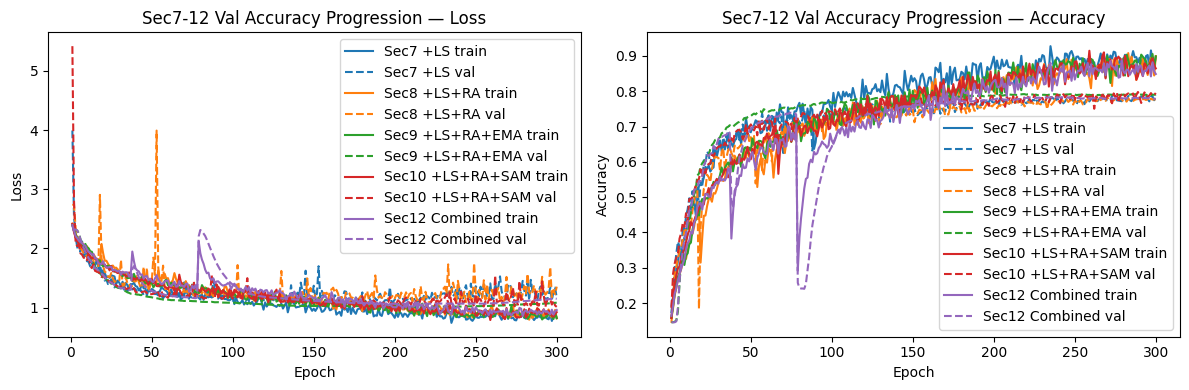

In [33]:
# ── Summary plot: val acc progression ────────────────────────────────────────
all_hists  = [hist7, hist8, hist9, hist10, history12]
all_labels = ['Sec7 +LS', 'Sec8 +LS+RA', 'Sec9 +LS+RA+EMA',
              'Sec10 +LS+RA+SAM', 'Sec12 Combined']
plot_curves(all_hists, all_labels, title='Sec7-12 Val Accuracy Progression')